In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from bitalg.tests.test2 import Test
from bitalg.visualizer.main import Visualizer
from functools import cmp_to_key

# Generowanie zbioru punktów za pomocą programu graficznego

In [140]:


%matplotlib tk

current_points=[]

def draw_point(point):
    plt.scatter(point[0],point[1],color="red")
    plt.show()


def onclick(event):
    global current_points

    if event.dblclick:
        if event.button==1:
            x=event.xdata
            y=event.ydata
            current_points.append((x,y))
            plt.scatter(x,y,color="red")
            plt.show()
        elif event.button==3:

            plt.pause(0.5)
            plt.pause(2)
            plt.close()
            return

fig,ax=plt.subplots()
plt.get_current_fig_manager()
connection_id=fig.canvas.mpl_connect("button_press_event",onclick)
ax.set_xlim([0,2])
ax.set_ylim([0,2])
plt.tight_layout()
plt.ion()
plt.show()

In [141]:
%matplotlib inline
current_points

[]

In [142]:
def generate_uniform_points(left=-500, right=500, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right),
                     np.random.uniform(left, right))
    return result

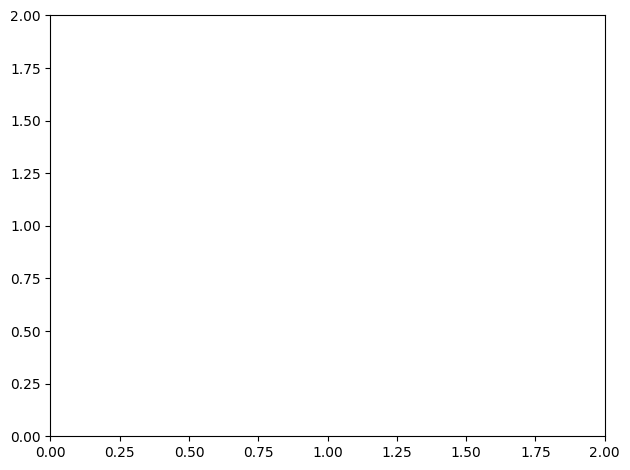

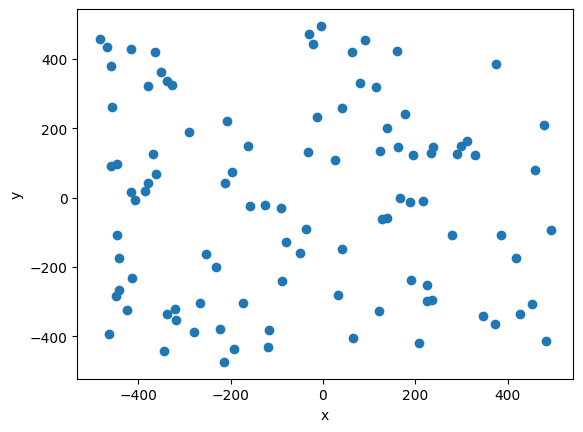

invalid command name "131329306342784process_stream_events"
    while executing
"131329306342784process_stream_events"
    ("after" script)


In [143]:
v = Visualizer()
points = generate_uniform_points(-500, 500, 100)
v.add_point(points)
v.show()

# Zbiory testowe

In [144]:
def generate_circle_points(O=(0, 0), R=20, n=100):
    """
    Funkcja generuje jednostajnie n punktów na okręgu o środku O i promieniu R
    :param O: krotka współrzędnych x, y określająca środek okręgu
    :param R: promień okręgu
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    result = [None for _ in range(n)]
    for i in range(n):
        t = np.random.uniform(0, 2 * np.pi)
        result[i] = (R*np.cos(t)+O[0], R*np.sin(t)+O[1])
    return result

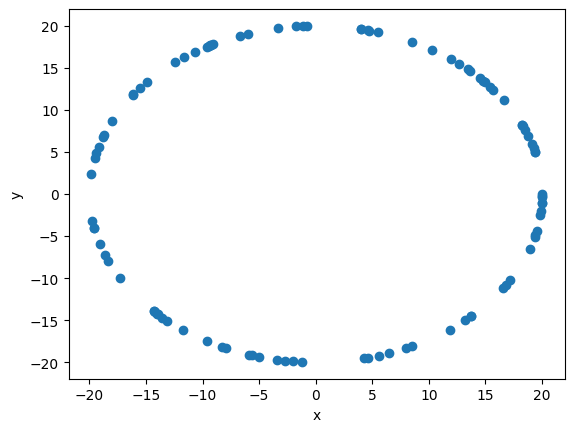

In [145]:
v.clear()
points_b = generate_circle_points()
v.add_point(points_b)
v.show()

In [146]:
def generate_rectangle_points(a=(-10, -10), b=(10, -10), c=(10, 10), d=(-10, 10), n=100):
    '''
    Funkcja generuje n punktów na obwodzie prostokąta
    o wierzchołkach w punktach a, b, c i d
    :param a: lewy-dolny wierzchołek prostokąta
    :param b: prawy-dolny wierzchołek prostokąta
    :param c: prawy-górny wierzchołek prostokąta
    :param d: lewy-górny wierzchołek prostokąta
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    '''
    res = [None for _ in range(n)]
    for i in range(n):
        side = np.random.randint(1, 5)
        if side == 1:
            x = np.random.uniform(a[0], b[0])
            res[i] = (x, a[1])
        elif side == 2:
            x = np.random.uniform(b[1], c[1])
            res[i] = (b[0], x)
        elif side == 3:
            x = np.random.uniform(c[0], d[0])
            res[i] = (x, c[1])
        else:
            x = np.random.uniform(d[1], a[1])
            res[i] = (d[0], x)
    return res

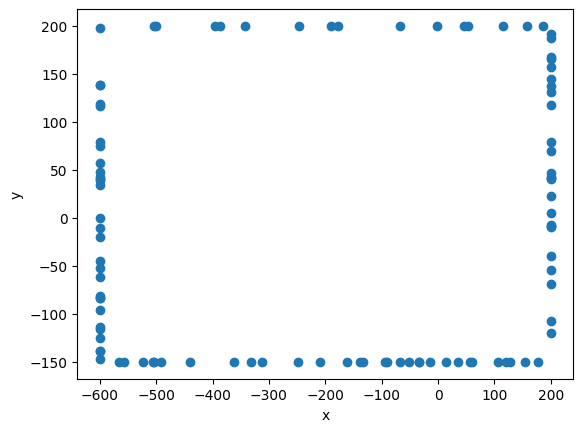

In [147]:
v.clear()
poinst_c = generate_rectangle_points(
    (-600, -150), (200, -150), (200, 200), (-600, 200), 100)
v.add_point(poinst_c)
v.show()

In [148]:
def generate_square_points(a=(0, 0), b=(10, 0), c=(10, 10), d=(0, 10),
                           axis_n=25, diag_n=20):
    '''
    Funkcja generuje axis_n punktów na dwóch bokach kwadratu
    leżących na osiach x i y oraz diag_n punktów na
    przektąnych kwadratu, którego wyznaczają punkty
    a, b, c i d.
    :param a: lewy-dolny wierzchołek kwadratu
    :param b: prawy-dolny wierzchołek kwadratu
    :param c: prawy-górny wierzchołek kwadratu
    :param d: lewy-górny wierzchołek kwadratu
    :param axis_n: ilość generowanych punktów na każdym
                   z dwóch boków kwadratu równoległych do osi x i y
    :param diag_n: ilość generowanych punktów na każdej
                   przekątnej kwadratu
    :return: tablica punktów w postaci krotek współrzędnych
    '''
    result = [a, b, c, d]
    for _ in range(axis_n):
        x = np.random.uniform(a[0], b[0])
        result.append((x, a[1]))

    for _ in range(axis_n):
        x = np.random.uniform(a[1], d[1])
        result.append((a[0], x))
    for _ in range(diag_n):
        x = np.random.uniform(a[1], d[1])
        result.append((x, x))

    for _ in range(diag_n):
        x = np.random.uniform(a[1], d[1])
        result.append((x, (d[1]-a[1])-x))
    return result

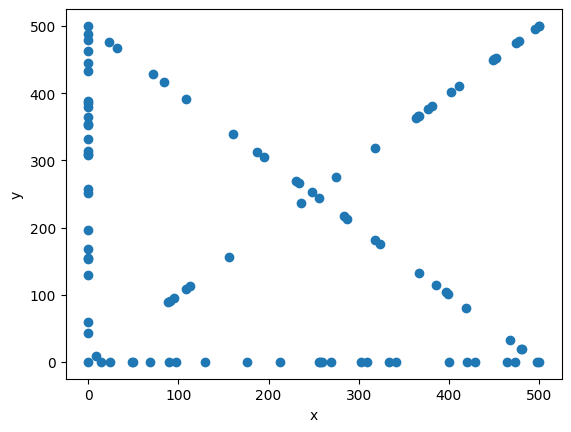

In [149]:
points_d = generate_square_points(
    (0, 0), (500, 0), (500, 500), (0, 500), (100-4)//4, (100-4)//4)
v.clear()
v.add_point(points_d)
v.show()

# Funkcje pomocniczne

In [150]:
def display_convex_hull(v,points,hull):
    v.clear()
    v.add_point(points)
    v.add_point(hull,color="red")
    v.add_line_segment([(hull[i], hull[i+1]) for i in range(len(hull)-1)],color="red")
    v.add_line_segment([hull[-1], hull[0]],color="red")
    v.show()

In [151]:
def mat_det_2x2(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return (a[0]-c[0])*(b[1]-c[1]) - (b[0]-c[0]) * (a[1]-c[1])


EPS = 10 ** (-24)


def orient(a, b, c):
    r = mat_det_2x2(a, b, c)
    if abs(r) < EPS:
        return 0
    elif r > 0:
        return 1
    else:
        return -1


def min_y(Q):
    n = len(Q)
    mini = Q[0]
    for i in range(n):
        if Q[i][1] < mini[1] or (Q[i][1] == mini[1] and Q[i][0] < mini[0]):
            mini = Q[i]
    return mini


def d(a, b):
    return (b[0]-a[0])**2+(b[1]-a[1])**2

# Graham

In [152]:
def compare(p0, p1, p2):
    r = orient(p0, p1, p2)
    if r == -1:
        return 1
    elif r == 1:
        return -1
    else:
        if d(p0, p2) >= d(p0, p1):
            return -1
        else:
            return 1


def rm_duplicates(Q, p0):
    result = [p0]
    n = len(Q)
    i = 2
    while i < n:
        while i < n and orient(p0, Q[i-1], Q[i]) == 0:

            i += 1
        result.append(Q[i-1])
        i += 1
    if len(Q) > 1 and i == n:
        result.append(Q[-1])
    return result


def graham_algorithm(Q):
    '''
    Funkcja buduje otoczkę wypukłą dla podanego
    zbioru punktów Q algorymem Grahama
    :parm Q: zbiór punktów
    :return: tablica punktów w postaci krotek współrzędnych
    
    '''
    Q = Q[:]
    p0 = min_y(Q)
    Q.sort(key=cmp_to_key(lambda a, b: compare(p0, a, b)))
    Q = rm_duplicates(Q, p0)
    m = len(Q)
    S = []
    for i in range(min(m, 3)):
        S.append(Q[i])
    for i in range(3, m):
        while len(S) > 2 and orient(S[-2], S[-1], Q[i]) != 1:
            S.pop()
        S.append(Q[i])
    return S


def graham_algorithm_draw(Q):
    '''
    Funkcja buduje otoczkę wypukłą dla podanego
    zbioru punktów Q algorymem Grahama oraz
    pokazuje poszczególne kroki algorymu
    :parm Q: zbiór punktów
    :return: krotka w postaci (tablica punktów w postaci krotek współrzędnych,
                                wizualizer pokazujący kroki algorytmu)
    '''
    v = Visualizer()
    Q = Q[:]
    p0 = min_y(Q)
    v.add_point(Q)
    Q.sort(key=cmp_to_key(lambda a, b: compare(p0, a, b)))
    Q = rm_duplicates(Q, p0)
    m = len(Q)
    E = []
    S = []
    for i in range(min(m, 3)):
        S.append(Q[i])
        v.add_point(Q[i], color="red")
    for i in range(1, len(S)):
        l = v.add_line_segment([S[i-1], S[i]], color="red")
        E.append(l)
    for i in range(3, m):
        while len(S) > 2 and orient(S[-2], S[-1], Q[i]) != 1:
            v.remove_figure(E.pop())
            v.add_point(S.pop(), color="brown")
        S.append(Q[i])
        v.add_point(S[-1], color="red")
        l = v.add_line_segment([S[-2], S[-1]], color="red")
        E.append(l)

    v.add_line_segment([S[-1], S[0]], color="red")
    return S, v

In [153]:
Test().runtest(1, graham_algorithm)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 1.941s


# Jarvis

In [154]:
def cmp(p0, p1, p2):
    r = orient(p0, p1, p2)
    if r == -1:
        return 1
    elif r == 1:
        return -1
    else:
        if d(p0, p2) < d(p0, p1):
            return -1
        else:
            return 1


def jarvis_algorithm(Q):
    '''
    Funkcja buduje otoczkę wypukłą dla podanego
    zbioru punktów Q algorymem Jarvisa
    :parm Q: zbiór punktów
    :return: tablica punktów w postaci krotek współrzędnych
    '''
    S = []
    n = len(Q)
    if n <= 2:
        return Q
    p0 = min_y(Q)
    p = p0
    while True:
        S.append(p)
        q = Q[1] if Q[0] == p else Q[0]
        for i in range(n):
            if cmp(p, Q[i], q) < 0:
                q = Q[i]
        p = q
        if p == p0:
            break
    return S


def jarvis_algorithm_draw(Q):
    '''
    Funkcja buduje otoczkę wypukłą dla podanego
    zbioru punktów Q algorymem Jarvisa oraz
    pokazuje poszczególne kroki algorymu
    :parm Q: zbiór punktów
    :return: krotka w postaci  (tablica punktów w postaci krotek współrzędnych,
                                wizualizer pokazujący kroki algorytmu)
    '''
    S = []
    v = Visualizer()
    v.add_point(Q)
    n = len(Q)
    if n <= 2:
        return Q
    p0 = min_y(Q)
    lines = []
    p = p0
    while True:
        S.append(p)
        v.add_point(p, color="red")
        q = Q[1] if Q[0] == p else Q[0]
        for i in range(n):
            if cmp(p, Q[i], q) < 0:
                if lines:
                    v.remove_figure(lines.pop())
                    v.remove_figure(point)
                q = Q[i]
                point = v.add_point(q, color="green")
                lines.append(v.add_line_segment((p, q), color="green"))
        v.add_line_segment((p, q), color="red")
        p = q
        if p == p0:
            break
    return S, v

In [155]:
Test().runtest(2, jarvis_algorithm)

Lab 2, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 1.851s


# Andrew

In [156]:

def Andrew(Q):
    if len(Q) <= 1:
        return Q
    # sortuje po x jeśli jest remis to po y
    # print(Q)
    Q = Q[:]
    Q.sort(key=lambda point: (point[0], point[1]))
    U = []
    L = []
    n = len(Q)
    # kolejność wyznacznia łańcuchów zapewnia
    # że wynik punktów do otoczki będzie przeciwnie du ruch wskazówek zegara
    for i in range(n):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(L) > 1 and not (orient(L[-2], L[-1], Q[i]) == 1):
            L.pop()
        L.append(Q[i])
    for i in range(n-1, -1, -1):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(U) > 1 and not (orient(U[-2], U[-1], Q[i]) == 1):
            U.pop()
        U.append(Q[i])
    U.pop()
    L.pop()
    convex_hull = L + U
    return convex_hull


def Andrew_vis(Q):
    v = Visualizer()
    blue = "#1f77b4"
    v.add_point(Q, color=blue)
    # sortuje po x jeśli jest remis to po y
    Q = Q[:]
    Q.sort(key=lambda point: (point[0], point[1]))
    U = []
    L = []
    n = len(Q)
    edges = []
    # kolejność wyznacznia łańcuchów zapewnia
    # że wynik punktów do otoczki będzie przeciwnie du ruch wskazówek zegara
    for i in range(n):
        # Sprawdzenie czy nie tworzą skrętu w lewo
        v.add_point(Q[i], color="green")
        if len(L) > 0:
            edges.append(v.add_line_segment([L[-1], Q[i]], color="green"))
        while len(L) > 1 and not (orient(L[-2], L[-1], Q[i]) == 1):
            v.remove_figure(edges.pop())
            v.remove_figure(edges.pop())
            x = L.pop()
            v.add_point(x, color=blue)
            edges.append(v.add_line_segment([L[-1], Q[i]], color="green"))
        L.append(Q[i])
    edges = []
    for i in range(n-1, -1, -1):
        v.add_point(Q[i], color="red")
        if len(U) > 0:
            edges.append(v.add_line_segment([U[-1], Q[i]], color="red"))
        # Sprawdzenie czy nie tworzą skrętu w lewo
        while len(U) > 1 and not (orient(U[-2], U[-1], Q[i]) == 1):
            v.remove_figure(edges.pop())
            v.remove_figure(edges.pop())
            x = U.pop()
            if x not in L:
                v.add_point(x, color=blue)
            else:
                v.add_point(x, color="green")
            edges.append(v.add_line_segment([U[-1], Q[i]], color="red"))
        U.append(Q[i])
    U.pop()
    L.pop()
    convex_hull = L + U
    return convex_hull, v

In [157]:
Test().runtest(2, Andrew)

Lab 2, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 0.466s


# Incremental

In [158]:
def update_upper(hull, point):
    while True:
        if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) <= 0:
            hull.pop()
        else:
            break


def update_lower(hull, point):
    while True:
        if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) >= 0:
            hull.pop()
        else:
            break


def Incremental(Q):
    n = len(Q)
    if n < 3:
        return Q
    Q = Q[:]
    Q.sort()
    upper = [Q[0]]
    lower = [Q[0]]
    for i in range(1, n):
        update_upper(upper, Q[i])
        update_lower(lower, Q[i])
        upper.append(Q[i])
        lower.append(Q[i])
    return lower[:-1] + upper[1:][::-1]


def Incremental_vis(Q):
    blue = "#1f77b4"
    Q = Q[:]

    def update_upper(hull, point):
        v.add_point(point, color='purple')
        while True:
            if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) < 0:
                v.add_point(hull.pop(), color=blue)
                v.remove_figure(u_edges.pop())
            else:

                break

    def update_lower(hull, point):
        while True:
            if len(hull) >= 2 and orient(point, hull[-1], hull[-2]) > 0:
                v.add_point(hull.pop(), color=blue)
                v.remove_figure(l_edges.pop())
            else:
                break

    v = Visualizer()
    v.add_point(Q, color=blue)

    n = len(Q)
    Q.sort()
    upper = [Q[0]]
    lower = [Q[0]]
    u_edges = []
    l_edges = []
    v.add_point(Q[0], color='green')
    for i in range(1, n):
        update_upper(upper, Q[i])
        update_lower(lower, Q[i])
        v.add_point(upper[1:], color='red')
        v.add_point(lower, color='green')
        upper.append(Q[i])
        lower.append(Q[i])
        u_edges.append(v.add_line_segment([upper[-2], upper[-1]], color='red'))
        l_edges.append(v.add_line_segment(
            [lower[-2], lower[-1]], color='green'))
    return lower[:-1] + upper[1:][::-1], v

In [159]:
Test().runtest(1, Incremental)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 0.685s


# Quickhull

In [160]:
def find_extreme_x_points(Q):
    min_x_point = min(Q, key=lambda p: (p[0], p[1]))
    max_x_point = max(Q, key=lambda p: (p[0], -p[1]))
    return min_x_point, max_x_point
# wysokość jest proporcjonalna do pola równologłoboku


def P(p1, p2, p):
    return mat_det_2x2(p1, p2, p)


def divide(Q, p1, p2):
    on_left = []
    on_right = []
    for point in Q:
        if point == p1 or point == p2:
            continue
        if orient(p1, p2, point) == 1:
            on_left.append(point)
        elif orient(p1, p2, point) == -1:
            on_right.append(point)
    return on_left, on_right


def farthest_point(S, p1, p2):
    max_P = -1
    res = -1
    for p in S:
        if p1 == p or p2 == p:
            continue
        if P(p1, p2, p) > max_P:
            res = p
            max_P = P(p1, p2, p)
    return res


def qhcompare(p0, p1, p2):
    r = orient(p0, p1, p2)
    if r == -1:
        return 1
    elif r == 1:
        return -1
    else:
        return 0


def quick_hull(points):
    if len(points) <= 2:
        return points
    p_min, p_max = find_extreme_x_points(points)
    CH = [p_min, p_max]

    def find_hull(S, A, B):
        nonlocal points, CH
        if not S:
            return
        C = farthest_point(S, A, B)
        if C == -1:
            return
        CH.append(C)
        left_to_ac, _ = divide(S, A, C)
        left_to_cb, _ = divide(S, C, B)
        find_hull(left_to_ac, A, C)
        find_hull(left_to_cb, C, B)
    on_left, on_right = divide(points, p_min, p_max)
    find_hull(on_left, p_min, p_max)
    find_hull(on_right, p_max, p_min)
    p0 = min_y(CH)
    CH.remove(p0)
    CH.sort(key=cmp_to_key(lambda a, b: qhcompare(p0, a, b)))
    CH.append(p0)
    return CH


def quick_hull_vis(points):
    vis = Visualizer()
    vis.add_point(points)
    p_min, p_max = find_extreme_x_points(points)
    CH = [p_min, p_max]

    def find_hull(S, A, B, last_line):
        nonlocal points, CH, vis
        if not S:
            return

        C = farthest_point(S, A, B)
        CH.append(C)
        vis.add_point(C, color="red")
        ac_line = vis.add_line_segment([A, C], color="red")
        cb_line = vis.add_line_segment([C, B], color="red")

        left_to_ac, _ = divide(S, A, C)
        left_to_cb, _ = divide(S, C, B)
        if last_line is not None:
            vis.remove_figure(last_line)

        find_hull(left_to_ac, A, C, ac_line)
        find_hull(left_to_cb, C, B, cb_line)
    vis.add_point(CH, color="red")
    on_left, on_right = divide(points, p_min, p_max)
    line = vis.add_line_segment([p_min, p_max], color="red")
    find_hull(on_left, p_min, p_max, None)
    find_hull(on_right, p_max, p_min, line)
    return vis

In [161]:
Test().runtest(1, quick_hull)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 2.190s


# Dziel i rządź

In [162]:
def merge_upper(l, r):
    l_len = len(l)
    r_len = len(r)
    if l_len == 0:
        return r
    if r_len == 0:
        return l
    i = l_len-1
    j = 0

    while (i-1 >= 0 and orient(l[i-1], l[i], r[j]) >= 0) or (j+1 < r_len and orient(l[i], r[j], r[j+1]) >= 0):
        if i-1 >= 0 and orient(l[i-1], l[i], r[j]) >= 0:
            i -= 1
        if j+1 < r_len and orient(l[i], r[j], r[j+1]) >= 0:
            j += 1

    return l[:i+1] + r[j:]


def merge_lower(l, r):
    l_len = len(l)
    r_len = len(r)
    if l_len == 0:
        return r
    if r_len == 0:
        return l
    i = l_len-1
    j = 0

    while (i-1 >= 0 and orient(l[i-1], l[i], r[j]) <= 0) or (j+1 < r_len and orient(l[i], r[j], r[j+1]) <= 0):
        if i-1 >= 0 and orient(l[i-1], l[i], r[j]) <= 0:
            i -= 1
        if j+1 < r_len and orient(l[i], r[j], r[j+1]) <= 0:
            j += 1

    return l[:i+1] + r[j:]


def partition(Q):
    n = len(Q)//2
    l = Q[:n]
    r = Q[n:]
    return l, r


def lower_hull(Q):
    if len(Q) < 3:
        return Q
    l, r = partition(Q)
    left = lower_hull(l)
    right = lower_hull(r)
    hull = merge_lower(left, right)
    return hull


def upper_hull(Q):
    if len(Q) < 3:
        return Q
    l, r = partition(Q)
    left = upper_hull(l)
    right = upper_hull(r)
    hull = merge_upper(left, right)
    return hull


def DivideAndConquer(Q):
    if len(Q) <= 2:
        return Q
    Q= Q[:]
    Q.sort()
    upper = upper_hull(Q)
    lower = lower_hull(Q)
    return lower[:-1] + upper[1:][::-1]

In [163]:
Test().runtest(1, DivideAndConquer)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: 

KeyboardInterrupt: 

# Chan

In [127]:
def bin_r_tangent(p, hull):

    n = len(hull)
    if n == 1:
        return 0
    if n == 2:
        if cmp(p, hull[0], hull[1]) < 0:
            return 0
        else:
            return 1
    # analizujemy wierzhołi od [v0, v1, .., vn]  gdzie vn = v0
    l, r = 0, len(hull)
    # sprawdzamy czy v0 jest wierzchołkiem stycznym
    if orient(p, hull[0], hull[1]) > 0 and orient(p, hull[0], hull[n - 1]) >= 0:
        return 0
    # print(p,hull)
    while True:
        c = (l+r)//2
        # print(l, c, r)
        # sprawdzamy, czy vc jest wierzchołkiem stycznym
        if orient(p, hull[c], hull[(c + 1) % n]) > 0 and orient(p, hull[c], hull[(c - 1) % n]) >= 0:
            return c
        # sprawdzamy czy wektor vl v(l+1) jest skierowany "do góry" <=> vl należy do łańcucha rosnącego
        if isEdgeIncreasing(hull, l, n, p):
            # sprawdzamy czy wektor vc v(c+1) jest skierowany "do dołu" <=> vc należy do łańcucha malejącego
            if isEdgeDecreasing(c, hull, n, p):
                # wierzchołek styczny będzie w przedziale [l,c]
                r = c
            # w innym przypadku vl należy vc należy do łańcucha rosnącego
            else:
                if orient(p, hull[l], hull[c]) < 0 or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    # wierzchołek styczny będzie w przedziale [c,r]
                    l = c
                else:
                    # wierzchołek styczny będzie w przedziale [l,c]
                    r = c

        else:
            if isEdgeIncreasing(hull, c, n, p):
                l = c
            else:
                if (orient(p, hull[l], hull[c]) < 0) or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    r = c
                else:
                    l = c
       


def isEdgeDecreasing(c, hull, n, p):
    return orient(p, hull[c], hull[(c + 1) % n]) > 0


def isEdgeIncreasing(hull, l, n, p):
    return orient(p, hull[l], hull[(l + 1) % n]) <= 0


def isCollinearAndApproachingP(c, hull, l, n, p):
    return ((orient(p, hull[l], hull[(l + 1) % n]) == 0 and d(p, hull[l]) > d(p, hull[(l + 1) % n])) or (
        orient(p, hull[c], hull[(c + 1) % n]) == 0 and d(p, hull[c]) > d(p, hull[(c + 1) % n]))) and orient(p, hull[l], hull[c]) == 0


def isCollinearAndDecreasingP(c, hull, l, n, p):
    return ((orient(p, hull[l], hull[(l + 1) % n]) == 0 and d(p, hull[l]) < d(p, hull[(l + 1) % n])) or (
        orient(p, hull[c], hull[(c + 1) % n]) == 0 and d(p, hull[c]) < d(p, hull[(c + 1) % n]))) and orient(p, hull[l], hull[c]) == 0


def cmp(p0, p1, p2):
    r = orient(p0, p1, p2)
    if r == -1:
        return 1
    elif r == 1:
        return -1
    else:
        if d(p0, p2) < d(p0, p1):
            return -1
        else:
            return 1


def Partial_Hull(P, m):
    hulls = [graham_algorithm(P[i:i + m]) for i in range(0, len(P), m)]
    r = len(hulls)
    hull = [(float('-inf'), 0), min_y(P)]
    for k in range(0, m):
        x = bin_r_tangent(hull[-1], hulls[0])
        q_max = hulls[0][x]
        for i in range(1, r):
            x = bin_r_tangent(hull[-1], hulls[i])
            q_i = hulls[i][x]
            if cmp(hull[-1], q_i, q_max) < 0:
                q_max = q_i
        if q_max == hull[1]:
            return hull
        hull.append(q_max)


def Convex_Hull(P):
    if len(P) <= 2:
        return P
    n = len(P)
    t = 1
    while True:
        m = min(n, 2**(2**t))
        hull = Partial_Hull(P, m)
        if hull is not None:
            return hull[1:]
        t += 1


def Partial_Hull_vis(P, m, vis):

    color_names = [
        'blue', 'green', 'yellow', 'blue', 'green', 'pink',
        'orange', 'purple', 'brown', 'cyan', 'magenta', 'lime',
        'indigo', 'violet', 'teal', 'turquoise', 'salmon',
        'coral', 'navy', 'lavender', 'gold', 'silver',
        'plum', 'beige', 'chartreuse', 'tan',
        'khaki', 'lavenderblush', 'forestgreen', 'lightblue', 'skyblue',
        'pearl', 'ivory', 'chocolate', 'seashell', 'wheat', 'antiquewhite',
        'midnightblue', 'darkorange', 'forestgreen', 'lightpink', 'slategray',
        'darkviolet', 'seagreen', 'mediumblue', 'aqua', 'orchid'
    ]

    hulls = [graham_algorithm(P[i:i + m]) for i in range(0, len(P), m)]
    hulls_vis = []
    hull_vis_points_w = []
    r = len(hulls)
    i = 0
    for hull in hulls:
        segmets = [(hull[i], hull[i+1]) for i in range(len(hull)-1)]
        segmets.append((hull[-1], hull[0]))
        hull_vis_points_w.append(vis.add_point(
            hull, color=color_names[i % len(color_names)]))
        hulls_vis.append(vis.add_line_segment(
            segmets, color=color_names[i % len(color_names)]))
        i += 1

    hull = [(float('-inf'), 0), min_y(P)]
    hull_vis_points = [vis.add_point(hull[1], color="red")]
    hull_vis_edges = []
    for k in range(0, m):
        x = bin_r_tangent(hull[-1], hulls[0])
        q_max = hulls[0][x]
        for i in range(1, r):
            x = bin_r_tangent(hull[-1], hulls[i])
            q_i = hulls[i][x]
            if cmp(hull[-1], q_i, q_max) < 0:
                hull_vis_edges.append(vis.add_line_segment(
                    [hull[-2], hull[-1]], color="red"))
                q_max = q_i
        if q_max == hull[1]:
            hull_vis_edges.append(vis.add_line_segment(
                [hull[-1], hull[1]], color="red"))
            return hull
        hull.append(q_max)
        hull_vis_points.append(vis.add_point(hull[-1], color="red"))
        hull_vis_edges.append(vis.add_line_segment(
            [hull[-2], hull[-1]], color="red"))
    for x in hulls_vis:
        vis.remove_figure(x)
    for x in hull_vis_points_w:
        vis.remove_figure(x)
    for x in hull_vis_edges:
        vis.remove_figure(x)
    for x in hull_vis_points:
        vis.remove_figure(x)


def Convex_Hull_vis(P):
    vis = Visualizer()
    vis.add_point(P)
    if len(P) <= 2:
        return P
    n = len(P)
    t = 1
    while True:
        m = min(n, 2**(2**t))
        hull = Partial_Hull_vis(P, m, vis)
        if hull is not None:

            return vis, hull[1:]
        t += 1


def bin_r_tangent_vis(p, hull):
    vis = Visualizer()
    vis.add_point(hull)
    vis.add_point(p, color="red")

    n = len(hull)
    if n == 1:
        return 0
    if n == 2:
        if cmp(p, hull[0], hull[1]) < 0:
            return 0
        else:
            return 1
    # analizujemy wierzhołi od [v0, v1, .., vn]  gdzie vn = v0
    l, r = 0, len(hull)
    l_vis, r_vis = vis.add_point(
        hull[0], color="green"), vis.add_point(hull[0], color="orange")
    # sprawdzamy czy v0 jest wierzchołkiem stycznym
    if orient(p, hull[0], hull[1]) > 0 and orient(p, hull[0], hull[n - 1]) >= 0:
        return 0
    while True:
        c = (l+r)//2
        c_vis = vis.add_point(hull[c], color="red")
        line = vis.add_line([p, hull[c]], color="red")
        # sprawdzamy, czy vc jest wierzchołkiem stycznym
        if orient(p, hull[c], hull[(c + 1) % n]) > 0 and orient(p, hull[c], hull[(c - 1) % n]) >= 0:
            return vis, c
        # vis.remove_figure(line)
        # sprawdzamy czy wektor vl v(l+1) jest skierowany "do góry" <=> vl należy do łańcucha rosnącego
        if isEdgeIncreasing(hull, l, n, p):
            # sprawdzamy czy wektor vc v(c+1) jest skierowany "do dołu" <=> vc należy do łańcucha malejącego
            if isEdgeDecreasing(c, hull, n, p):
                # wierzchołek styczny będzie w przedziale [l,c]
                r = c
                vis.remove_figure(c_vis)
                vis.remove_figure(r_vis)
                r_vis = vis.add_point(hull[r], color="orange")
            # w innym przypadku vl należy vc należy do łańcucha rosnącego
            else:
                if orient(p, hull[l], hull[c]) < 0 or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    # wierzchołek styczny będzie w przedziale [c,r]
                    l = c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(l_vis)
                    l_vis = vis.add_point(hull[l], color="green")
                else:
                    # wierzchołek styczny będzie w przedziale [l,c]
                    r = c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(r_vis)
                    r_vis = vis.add_point(hull[r], color="orange")

        else:
            if isEdgeIncreasing(hull, c, n, p):
                l = c
                vis.remove_figure(c_vis)
                vis.remove_figure(l_vis)
                l_vis = vis.add_point(hull[l], color="green")
            else:
                if (orient(p, hull[l], hull[c]) < 0) or (isCollinearAndDecreasingP(c, hull, l, n, p) and d(p, hull[l]) < d(p, hull[(c) % n])) or (isCollinearAndApproachingP(c, hull, l, n, p) and d(p, hull[l]) > d(p, hull[(c) % n])):
                    r = c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(r_vis)
                    r_vis = vis.add_point(hull[r], color="orange")
                else:
                    l = c
                    vis.remove_figure(c_vis)
                    vis.remove_figure(r_vis)
                    r_vis = vis.add_point(hull[r], color="orange")
        vis.remove_figure(line)

In [ ]:
Test().runtest(1, Convex_Hull)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 6.966s


# Test

In [129]:
# np.random.seed(935212313)
np.random.seed(234431)


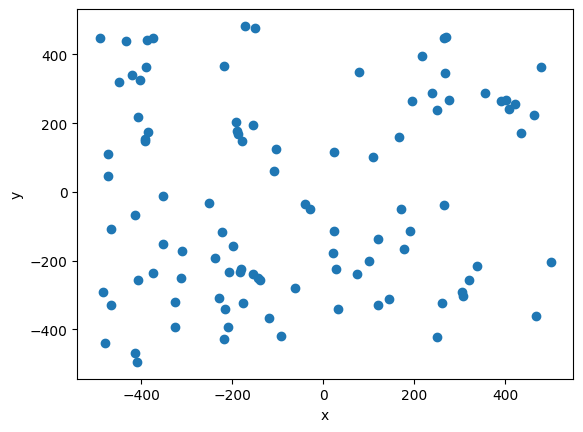

In [ ]:
v = Visualizer()
points_1 = generate_uniform_points(-500, 500, 100)
v.add_point(points_1)
v.show()

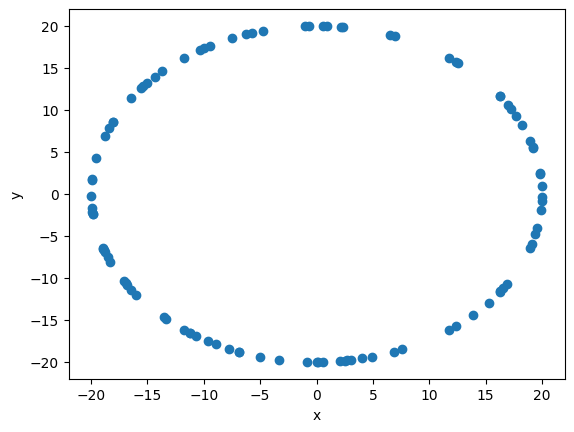

In [ ]:
v.clear()
points_2 = generate_circle_points()
v.add_point(points_2)
v.show()

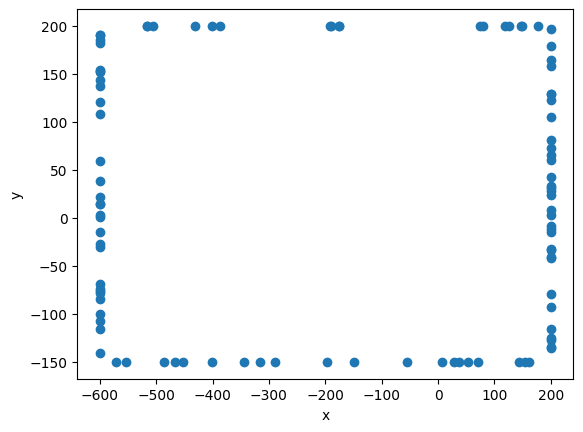

In [ ]:
v.clear()
poinst_3 = generate_rectangle_points(
    (-600, -150), (200, -150), (200, 200), (-600, 200), 100)
v.add_point(poinst_3)
v.show()

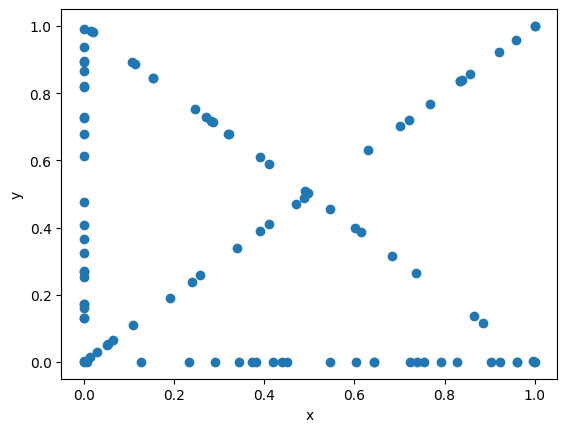

In [ ]:
points_4 = generate_square_points(
    (0, 0), (1, 0), (1, 1), (1, 1), (100-4)//4, (100-4)//4)
v.clear()
v.add_point(points_4)
v.show()

# Uzyskane wyniki

In [134]:
algorytmy = [graham_algorithm, jarvis_algorithm,
             Andrew, Incremental, quick_hull, DivideAndConquer, Convex_Hull]
labels = ["Algorytm Grahama", "Algorytm Jarvisa", "Algorytm Andrewsa",
          "Algorytm przyrostowy","Algorytm dziel i rządź", "Algorytm QuickHull", "Algorytm Chana"]


In [135]:
import time
import pandas as pd
import matplotlib.pyplot as plt


def generate_test(points, name, algorithms, labels):
    if len(algorithms) != len(labels):
        raise ValueError("Liczba algorytmów musi być równa liczbie etykiet.")

    # Przygotowanie tabeli wynikowej
    table = {"ilość": []}
    for label in labels:
        table[label] = []
    i=1
    for point_set in points:
        table["ilość"].append(f"Zbiór {i}")

        for alg, label in zip(algorithms, labels):
            result = alg(point_set)
            table[label].append(len(result))
        i+=1


    # Tworzenie DataFrame
    df = pd.DataFrame(data=table)


    # Aktualizacja nazw kolumn w DataFrame
    column_names = ["Zbiór"] + [
        f"Liczba punktów otoczki wypukłej dla {label}" for label in labels
    ]
    df.columns = column_names

    print(df.to_string(index=False))
    df.to_csv(f"{name}.csv", index=False)

In [136]:
# x = Convex_Hull(points_4)
# p = [(219.75802591672482, 0), (224.7567366279043, 0), (244.0061352397615, 244.0061352397615), (235.72354606166206, 235.72354606166206)]
# v.clear()
# v.add_point(p)
# v.add_point((0,0), color="red")
# bin_r_tangent((0,0), p)
# v.show()
p = [points_1, points_2, poinst_3, points_4]
generate_test(p, "test", algorytmy, labels)

  Zbiór  Liczba punktów otoczki wypukłej dla Algorytm Grahama  Liczba punktów otoczki wypukłej dla Algorytm Jarvisa  Liczba punktów otoczki wypukłej dla Algorytm Andrewsa  Liczba punktów otoczki wypukłej dla Algorytm przyrostowy  Liczba punktów otoczki wypukłej dla Algorytm dziel i rządź  Liczba punktów otoczki wypukłej dla Algorytm QuickHull  Liczba punktów otoczki wypukłej dla Algorytm Chana
Zbiór 1                                                    10                                                    10                                                     10                                                        10                                                          10                                                      10                                                  10
Zbiór 2                                                   100                                                   100                                                    100                                    

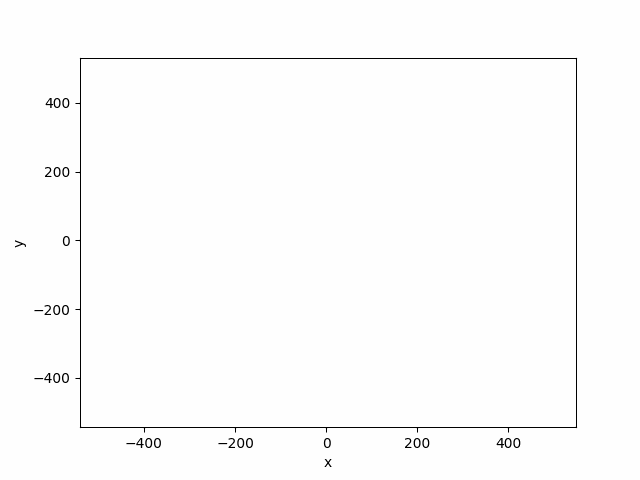

In [ ]:
v, l = Convex_Hull_vis(points_1)
v.show_gif()

Time: 0.000s


KeyboardInterrupt: 

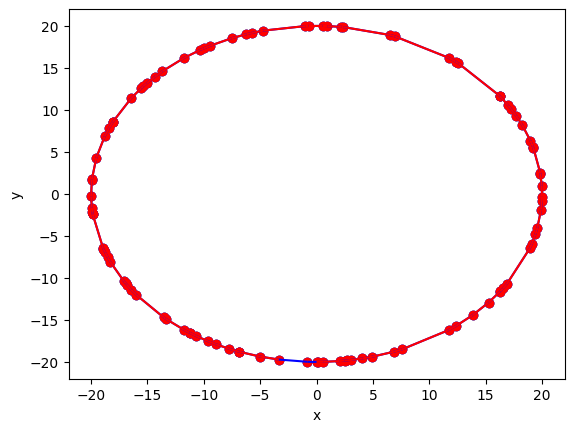

In [ ]:
v, l = Convex_Hull_vis(points_2)
v.show_gif()

# Czas działania


In [37]:
# np.random.seed(935213)

np.random.seed(93521233)
number_points = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
np_b = np.linspace(1000, 10000, 10, dtype=int)
# number_points = np.linspace(1000, 1000000, 10, dtype=int)
# number_points_b = [10, 100, 500, 1000, 2000,
#                    3000, 4000, 5000, 7000, 9000, 10000]
new_points_a = [generate_uniform_points(-500, 500, number_points[i])
                for i in range(len(number_points))]
new_points_b = [generate_circle_points(
    (0, 0), 20, np_b[i]) for i in range(len(np_b))]
new_points_c = [generate_rectangle_points(
    (-600, -150), (200, -150), (200, 200), (-600, 200), number_points[i]) for i in range(len(number_points))]
# new_points_d = [generate_square_points((0, 0), (500, 0), (500, 500), (0, 500), (
#     number_points[i]-4)//4, (number_points[i]-4)//4) for i in range(len(number_points))]
new_points_d = [generate_square_points((0, 0), (1, 0), (1, 1), (0, 1), (
    number_points[i]-4)//4, (number_points[i]-4)//4) for i in range(len(number_points))]
algorytmy = [graham_algorithm, jarvis_algorithm,
             Andrew, Incremental, quick_hull, DivideAndConquer, Convex_Hull]
labels = ["Algorytm Grahama", "Algorytm Jarvisa", "Algorytm górnej i dolenj otoczki",
          "Algorytm przyrostowy","Algorytm dziel i rządź", "Algorytm QuickHull", "Algorytm Chana"]

In [38]:
print(number_points, list(np_b))

[1000, 5000, 10000, 50000, 100000, 500000, 1000000] [np.int64(1000), np.int64(2000), np.int64(3000), np.int64(4000), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(9000), np.int64(10000)]


In [39]:
import time
import pandas as pd
import matplotlib.pyplot as plt


def generate_comparison_table(points, name, algorithms, labels):
    """
    Funkcja do generowania tabeli porównawczej i wykresów dla wielu algorytmów.

    :param points: Lista zbiorów punktów do przetwarzania.
    :param name: Nazwa pliku wynikowego (CSV).
    :param algorithms: Lista funkcji algorytmów do testowania.
    :param labels: Lista nazw algorytmów odpowiadająca funkcjom w 'algorithms'.
    """
    if len(algorithms) != len(labels):
        raise ValueError("Liczba algorytmów musi być równa liczbie etykiet.")

    # Przygotowanie tabeli wynikowej
    table = {"ilość": []}
    for label in labels:
        table[label] = []

    for point_set in points:
        n = len(point_set)
        table["ilość"].append(n)

        otoczka_len = None
        for alg, label in zip(algorithms, labels):
            # Pomiar czasu wykonania algorytmu
            # print(alg.__name__)
            start = time.time()
            result = alg(point_set)
            end = time.time()
            execution_time = round(end - start, 4)
            # print(alg.__name__, "end")
            # Dodanie wyników do tabeli
            if otoczka_len is None:
                # Zakładamy, że każdy algorytm zwraca otoczkę o tej samej liczbie punktów
                otoczka_len = len(result)
            table[label].append(execution_time)


    # Tworzenie DataFrame
    df = pd.DataFrame(data=table)

    # Tworzenie wykresu
    for label in labels:
        plt.plot(table["ilość"], table[label], label=label)

    plt.xlabel("Liczebność zbioru")
    plt.ylabel("Czas wykonania algorytmu [s]")
    plt.grid(True)
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    plt.legend()
    plt.show()

    # Aktualizacja nazw kolumn w DataFrame
    column_names = ["Liczebność zbioru"] + [
        f"Czas wykonania dla {label} [s]" for label in labels
    ]
    df.columns = column_names

    print(df.to_string(index=False))
    df.to_csv(f"{name}.csv", index=False)

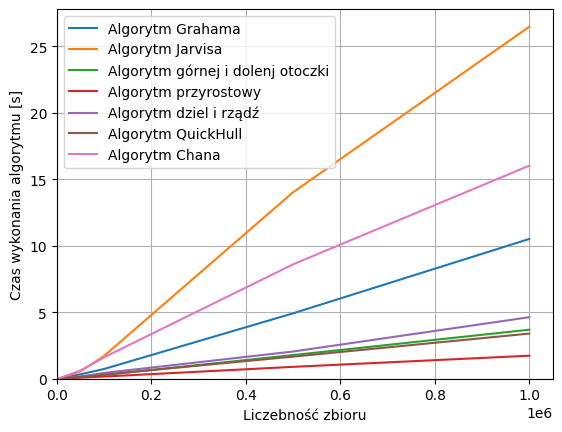

 Liczebność zbioru  Czas wykonania dla Algorytm Grahama [s]  Czas wykonania dla Algorytm Jarvisa [s]  Czas wykonania dla Algorytm górnej i dolenj otoczki [s]  Czas wykonania dla Algorytm przyrostowy [s]  Czas wykonania dla Algorytm dziel i rządź [s]  Czas wykonania dla Algorytm QuickHull [s]  Czas wykonania dla Algorytm Chana [s]
              1000                                   0.0029                                   0.0065                                                   0.0015                                       0.0012                                         0.0023                                     0.0023                                 0.0085
              5000                                   0.0189                                   0.0258                                                   0.0073                                       0.0054                                         0.0099                                     0.0115                                 0.0457
    

In [39]:

# algorytmy = [graham_algorithm, jarvis_algorithm, Andrew, Incremental, quickhull_algorithm, Convex_Hull]
# labels = ["Algorytm Grahama", "Algorytm Jarvisa", "Algorytm Andrewsa", "Algorytm przyrostowy", "Algorytm QuickHull", "Algorytm Chana"]
generate_comparison_table(
    new_points_a, "porównanie_algorytmów_a1", algorytmy, labels)

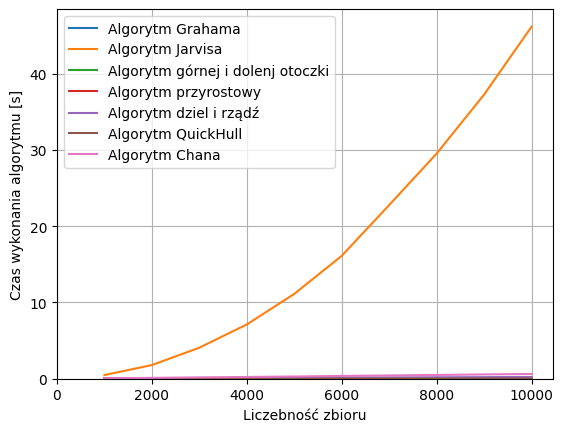

 Liczebność zbioru  Czas wykonania dla Algorytm Grahama [s]  Czas wykonania dla Algorytm Jarvisa [s]  Czas wykonania dla Algorytm górnej i dolenj otoczki [s]  Czas wykonania dla Algorytm przyrostowy [s]  Czas wykonania dla Algorytm dziel i rządź [s]  Czas wykonania dla Algorytm QuickHull [s]  Czas wykonania dla Algorytm Chana [s]
              1000                                   0.0050                                   0.4795                                                   0.0021                                       0.0016                                         0.0178                                     0.0024                                 0.0576
              2000                                   0.0108                                   1.7894                                                   0.0035                                       0.0029                                         0.0388                                     0.0049                                 0.1141
    

In [40]:
generate_comparison_table(
    new_points_b, "porównanie_algorytmów_b1", algorytmy, labels)

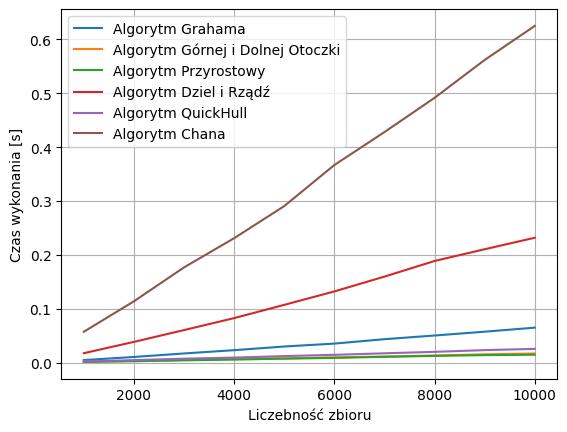

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytanie danych z pliku CSV
data = pd.read_csv('porównanie_algorytmów_b.csv')  # Zastąp 'plik.csv' odpowiednią ścieżką do pliku CSV


# Algorytmy
plt.plot(data['Liczebność zbioru'], data['Czas wykonania dla Algorytm Grahama [s]'], label='Algorytm Grahama')
# plt.plot(data['Liczebność zbioru'], data['Czas wykonania dla Algorytm Jarvisa [s]'], label='Algorytm Jarvisa')
plt.plot(data['Liczebność zbioru'], data['Czas wykonania dla Algorytm górnej i dolenj otoczki [s]'], label='Algorytm Górnej i Dolnej Otoczki')
plt.plot(data['Liczebność zbioru'], data['Czas wykonania dla Algorytm przyrostowy [s]'], label='Algorytm Przyrostowy')
plt.plot(data['Liczebność zbioru'], data['Czas wykonania dla Algorytm dziel i rządź [s]'], label='Algorytm Dziel i Rządź')
plt.plot(data['Liczebność zbioru'], data['Czas wykonania dla Algorytm QuickHull [s]'], label='Algorytm QuickHull')
plt.plot(data['Liczebność zbioru'], data['Czas wykonania dla Algorytm Chana [s]'], label='Algorytm Chana')

# Dodanie etykiet i tytułu
plt.xlabel('Liczebność zbioru')
plt.ylabel('Czas wykonania [s]')
plt.legend()

# Wyświetlenie wykresu
plt.grid(True)
plt.show()


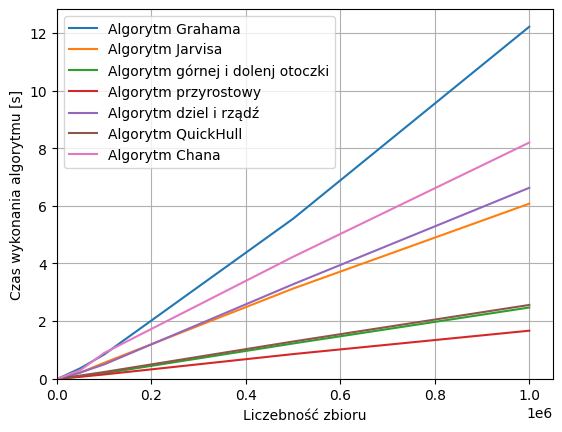

 Liczebność zbioru  Czas wykonania dla Algorytm Grahama [s]  Czas wykonania dla Algorytm Jarvisa [s]  Czas wykonania dla Algorytm górnej i dolenj otoczki [s]  Czas wykonania dla Algorytm przyrostowy [s]  Czas wykonania dla Algorytm dziel i rządź [s]  Czas wykonania dla Algorytm QuickHull [s]  Czas wykonania dla Algorytm Chana [s]
              1000                                   0.0039                                   0.0032                                                   0.0012                                       0.0011                                         0.0054                                     0.0027                                 0.0060
              5000                                   0.0269                                   0.0154                                                   0.0068                                       0.0065                                         0.0155                                     0.0091                                 0.0266
    

In [41]:
generate_comparison_table(
    new_points_c, "porównanie_algorytmów_c1", algorytmy, labels)

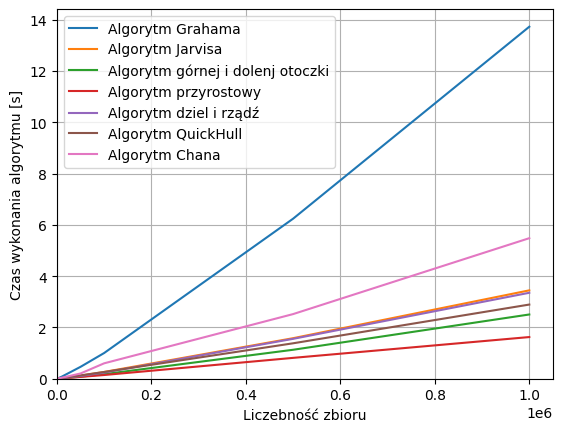

 Liczebność zbioru  Czas wykonania dla Algorytm Grahama [s]  Czas wykonania dla Algorytm Jarvisa [s]  Czas wykonania dla Algorytm górnej i dolenj otoczki [s]  Czas wykonania dla Algorytm przyrostowy [s]  Czas wykonania dla Algorytm dziel i rządź [s]  Czas wykonania dla Algorytm QuickHull [s]  Czas wykonania dla Algorytm Chana [s]
              1000                                   0.0081                                   0.0034                                                   0.0018                                       0.0016                                         0.0027                                     0.0032                                 0.0054
              5000                                   0.0368                                   0.0106                                                   0.0067                                       0.0062                                         0.0090                                     0.0118                                 0.0197
    

In [40]:
generate_comparison_table(
    new_points_d, "porównanie_algorytmów_d1", algorytmy, labels)